# BEE 4750 Lab 2: Monte Carlo

**Name**: Natalie Ho

**ID**: nh424

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [21]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/hw2-natalie/lab-2-NatalieHo424`


In [22]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [23]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [24]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

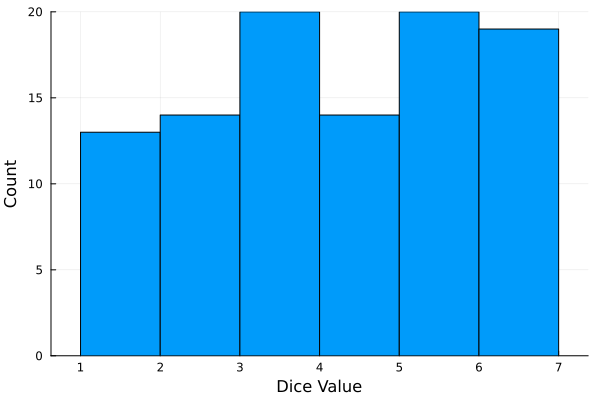

In [25]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

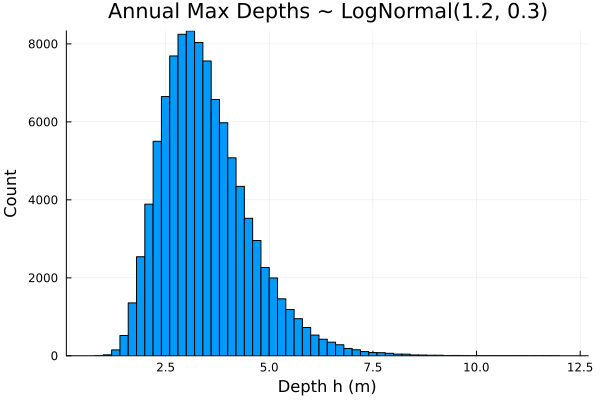

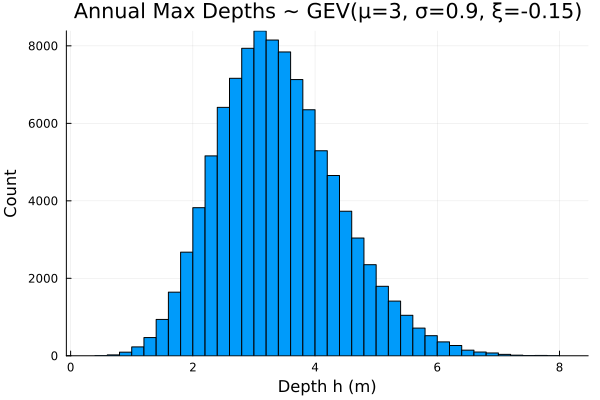

In [30]:
using Plots, Random, Distributions

Random.seed!(1)

# Depth–damage parameters
L  = 200_000.0
k  = 0.8
h0 = 3.0

#Logistic Function 
d_of_h(h) = (h > 0) ? L / (1 + exp(-k*(h - h0))) : 0.0

# Hazard distributions
dist_logn = LogNormal(1.2, 0.3)
dist_gev  = GeneralizedExtremeValue(3.0, 0.9, -0.15)

# Samples
n = 100_000
h_logn = rand(dist_logn, n)
h_gev  = rand(dist_gev,  n)

# Plots
plot1 = histogram(h_logn; bins=60, xlabel="Depth h (m)", ylabel="Count",title="Annual Max Depths ~ LogNormal(1.2, 0.3)", label=false)
display(plot1)

plot2 = histogram(h_gev; bins=60, xlabel="Depth h (m)", ylabel="Count",title="Annual Max Depths ~ GEV(μ=3, σ=0.9, ξ=-0.15)", label=false)
display(plot2)

For plotting of the histograms, I solved this question by writing out the parameters provided in the problem and then applied the logitisc function regonzining that I needed to also include : 0 in the function so that the function is defined as when I didn't have this in at first, I was getting an error message. I then used the dice roll exanple code provided to apply that to this problem and and I was able to produce these histograms shown above. I notice through these histograms that the LogNormal plot looks to be right skewed. After doing more research I learned that most times LogNormal plots are positively skewed with long right tails due to low mean values and high variances in the random variables. The GeneralizedExtremeValue (GEV) plot shows to be more uniform than the LogNormal Plot. We could predict this by looking at the given shape value: -0.15. 

In [32]:
using Statistics

# Convert sampled depths into damages because we are trying to estamte flood damge to a house without a basement
d_logn = d_of_h.(h_logn)
d_gev  = d_of_h.(h_gev)

# Monte Carlo Summaries
mean_logn = mean(d_logn)
mean_gev  = mean(d_gev)

se_mean_logn = std(d_logn) / sqrt(length(d_logn))
se_mean_gev  = std(d_gev)  / sqrt(length(d_gev))

q99_logn = quantile(d_logn, 0.99)
q99_gev  = quantile(d_gev,  0.99)

# Results
println("Monte Carlo results (n = $n)\n")

println("LogNormal results:")
println("  Expected damage (mean) = ", round(mean_logn, digits=2))
println("  Standard error of mean = ", round(se_mean_logn, digits=2))
println("  99th percentile of damages = ", round(q99_logn, digits=2))
println()

println("GEV results:")
println("  Expected damage (mean) = ", round(mean_gev, digits=2))
println("  Standard error of mean = ", round(se_mean_gev, digits=2))
println("  99th percentile of damages = ", round(q99_gev, digits=2))


Monte Carlo results (n = 100000)

LogNormal results:
  Expected damage (mean) = 115307.29
  Standard error of mean = 108.48
  99th percentile of damages = 190131.39

GEV results:
  Expected damage (mean) = 113568.49
  Standard error of mean = 106.35
  99th percentile of damages = 183428.44


## Monte Carlo Analysis of Annual Maximum Flood Damages

I modeled annual maximum flood depths using two candidate distributions:  
1. $h \sim \text{LogNormal}(\mu = 1.2, \sigma = 0.3)$  
2. $h \sim \text{GEV}(\mu = 3.0, \sigma = 0.9, \xi = -0.15)$  

I then mapped each depth sample into a monetary loss using the bounded logistic depth–damage function:

$$
d(h) = 
\begin{cases}
\dfrac{L}{1 + e^{-k(h-h_0)}}, & h > 0 \\
0, & h \leq 0
\end{cases}
$$

with parameters $L = 200{,}000 \,\text{USD}$ (maximum possible loss), $k = 0.8$ (slope), and $h_0 = 3.0 \,\text{m}$ (inflection depth).  
This function makes sure that damages are zero below the floor and saturate at the maximum loss for very deep floods. This reasoning was provided to us in class.

### Results: Monte Carlo Estimates

Using $n = 100{,}000$ samples from each distribution:

- **LogNormal Characterization**
  - Expected annual maximum damage: $\mathbb{E}[D] \approx \$115{,}307.29$  
  - Standard error of the mean: $SE(\hat{E}[D]) \approx \$108.48$  
  - 99th percentile damage: $Q_{0.99}(D) \approx \$190{,}131.39$  

- **GEV Characterization**
  - Expected annual maximum damage: $\mathbb{E}[D] \approx \$113{,}568.49$  
  - Standard error of the mean: $SE(\hat{E}[D]) \approx \$106.35$  
  - 99th percentile damage: $Q_{0.99}(D) \approx \$183{,}428.44$  

I see from the results here that both models yield similar estimates. However, the LogNormal Characterization consisitantly has greater values for the expected annual mean damage, standard error of the mean, and 99th percentile damage. This make sense because the LogNormal produces slightly higher values because of its heavier right tail.


### Choice of Sample Size

I used $n = 100{,}000$ samples for each distribution to ensure statistical accuracy and computational efficiency.  My reasoning is provided below. 

The Monte Carlo standard error (SE) of the sample mean is given by

$$
SE(\hat{E}[D]) = \frac{s}{\sqrt{n}},
$$

where $s$ is the sample standard deviation of damages. I ran the code for calcualting this value below. For our simulations, $s\approx 33{,}631$
 but for this case I assumed, $s \approx 34{,}000$. With $n = 100{,}000$, the standard error of the mean becomes

$$
SE(\hat{E}[D]) \approx \frac{34{,}000}{\sqrt{100{,}000}} \approx 108 \,\text{USD},
$$

which is very small compared to mean damages of up to $\$100{,}000$.

I also tested smaller $n$ values to see how this value changes: 
- At $n = 10{,}000$, the SE was about $\$340$, still small but large enough that repeated runs caused noticeable variation in the estimated 99th percentile.  
- At $n = 1{,}000$, the SE grew to about $\$1{,}080$, which is way too large for precise reporting.

I then compared these values to the 99th percentile. For the **99th percentile**, I believe that accuracy depends not only on $n$ but also on how many samples actually fall in the upper 1% of the distribution. With $n = 100{,}000$, I have about $1{,}000$ data points in the top 1%, which provides a stable estimate of $Q_{0.99}$. With $n = 10{,}000$, only about $100$ points fall in the top 1%, which makes the quantile estimate less stable and more sensitive to random variation. Thus, I went with the larger sample size number of 100,000 as I found this to be a better representation of data accurarcy for this problem. 

In summary, I choose  $n = 100{,}000$ because:
1. It reduces the standard error of the mean to less than 0.1% of the expected damage.  
2. It provides enough data in the extreme tail (≈1,000 values above the 99th percentile) to yield a stable estimate of $Q_{0.99}$.  

Thus, I believe this makes $n = 100{,}000$ a reasonable choice for accurate and efficient Monte Carlo estimation.


### Why the Estimates may Differ

The two distributions differ in tail behavior:

- The **GEV distribution** with $\xi = -0.15$ has an upper bound on flood depth at  
  $$
  h_{\max} = \mu - \frac{\sigma}{\xi} = 3.0 - \frac{0.9}{-0.15} \approx 9 \,\text{m}.
  $$
  This caps the maximum simulated depth.

- The **LogNormal distribution** has an unbounded right tail, allowing for occasional extreme depths.

However, the logistic damage function seems to have an **upper limit** meaning once depths exceed about $5{-}6 \,\text{m}$, the predicted damages approach the maximum loss $L = 200{,}000$. At this point, additional increases in flood depth produce almost no further change in the estimated damage, since the curve levels off near its maximum value.

As a result:
- Both distributions produce very similar expected damages.  
- The LogNormal produces slightly higher 99th percentiles due to its heavier tail, but the differences are small because of the damage cap.

Also, the two hazard distributions differ not only in their tails but also in their **overall shape**, which affects how much probability mass falls near the steepest part of the depth–damage curve around $h_0 = 3 \,\text{m}$.  

- The **GEV distribution** with $\xi = -0.15$ is more concentrated, with an upper bound around $9 \,\text{m}$. This means fewer simulated floods fall far into the extreme range, and more probability mass is clustered around its location parameter $\mu = 3 \,\text{m}$.  
- The **LogNormal distribution** is positively skewed, with a longer right tail and more spread. This allows a higher chance of producing depths just above the inflection point $h_0$, where damages rise most rapidly. Even before considering the far tail, this broader shape increases the likelihood of drawing damaging depths.  

Because the depth–damage function grows quickly between $2{-}5 \,\text{m}$ and then levels off near $L = 200{,}000$, the **shape of the distribution around this critical region** has a strong influence on both the expected damages and the estimated 99th percentile. The LogNormal’s skew and spread push more samples into this high-sensitivity zone, producing slightly larger damage estimates compared to the GEV.

### Deciding Which Distribution is “Better”
To decide on which values fit better, I would want to reference more additional information.

1. **Shape and physical plausibility**: The GEV with $\xi < 0$ imposes an upper bound on flood depth (about $9 \,\text{m}$ here), which may be realistic if there are physical limits such as levees or watershed capacity. The LogNormal, by contrast, has a positively skewed, unbounded tail, which could be more appropriate in settings where extreme depths are theoretically possible.  

2. **Predictive performance for extremes**: Since damages are highly sensitive to flood depths just above the threshold $h_0$, the model that best predicts the upper quantiles (e.g., 95th–99th percentiles) will provide more reliable risk estimates. Cross-validation with historical extreme events would help decide this.  

3. **Decision sensitivity**: The choice of distribution matters most if decisions (insurance pricing, design standards, or retrofit investments) change depending on the expected loss or high quantile estimates. If outcomes are robust across models, then the exact choice is less critical.  

Thus, additional hydrologic and site-specific data would be needed to determine which distribution is better. Both models could be reasonable. The GEV is often preferred because it is designed specifically for analyzing annual maximum events, while the LogNormal can be useful when we expect more skewed data and the possibility of very large, unbounded flood depths.

In [33]:
std(d_logn)
std(d_gev)


33631.28242594318

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

I referenced the website Statistics How To, to get a better understanding of the GEV distribution because I wanted to know more about what the values provided represent. I learned that the last value provided tells us the shape. 